<a href="https://colab.research.google.com/github/Chaitanya-G15/Rainfall-Prediction-ML-Model/blob/main/ML_Rainfall_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix
import pickle

In [3]:
data = pd.read_csv('Rainfall.csv')

In [4]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [5]:
data.shape

(366, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [7]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [8]:
data.columns = data.columns.str.strip()

In [9]:
data.isnull().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [10]:
data['winddirection'] = data['winddirection'].fillna(data['winddirection'].mode()[0]) # As windirection have numberic values
data['windspeed'] = data['windspeed'].fillna(data['windspeed'].median())

In [11]:
data = data.drop(columns=['day'])

In [12]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [13]:
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [14]:
data['rainfall'] = data['rainfall'].map({"yes":1,"no": 0})

In [15]:
data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


#### Exploratory Data Analysis

In [16]:
data.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

##### **Observation:** Distribution of data in each feature is skewed

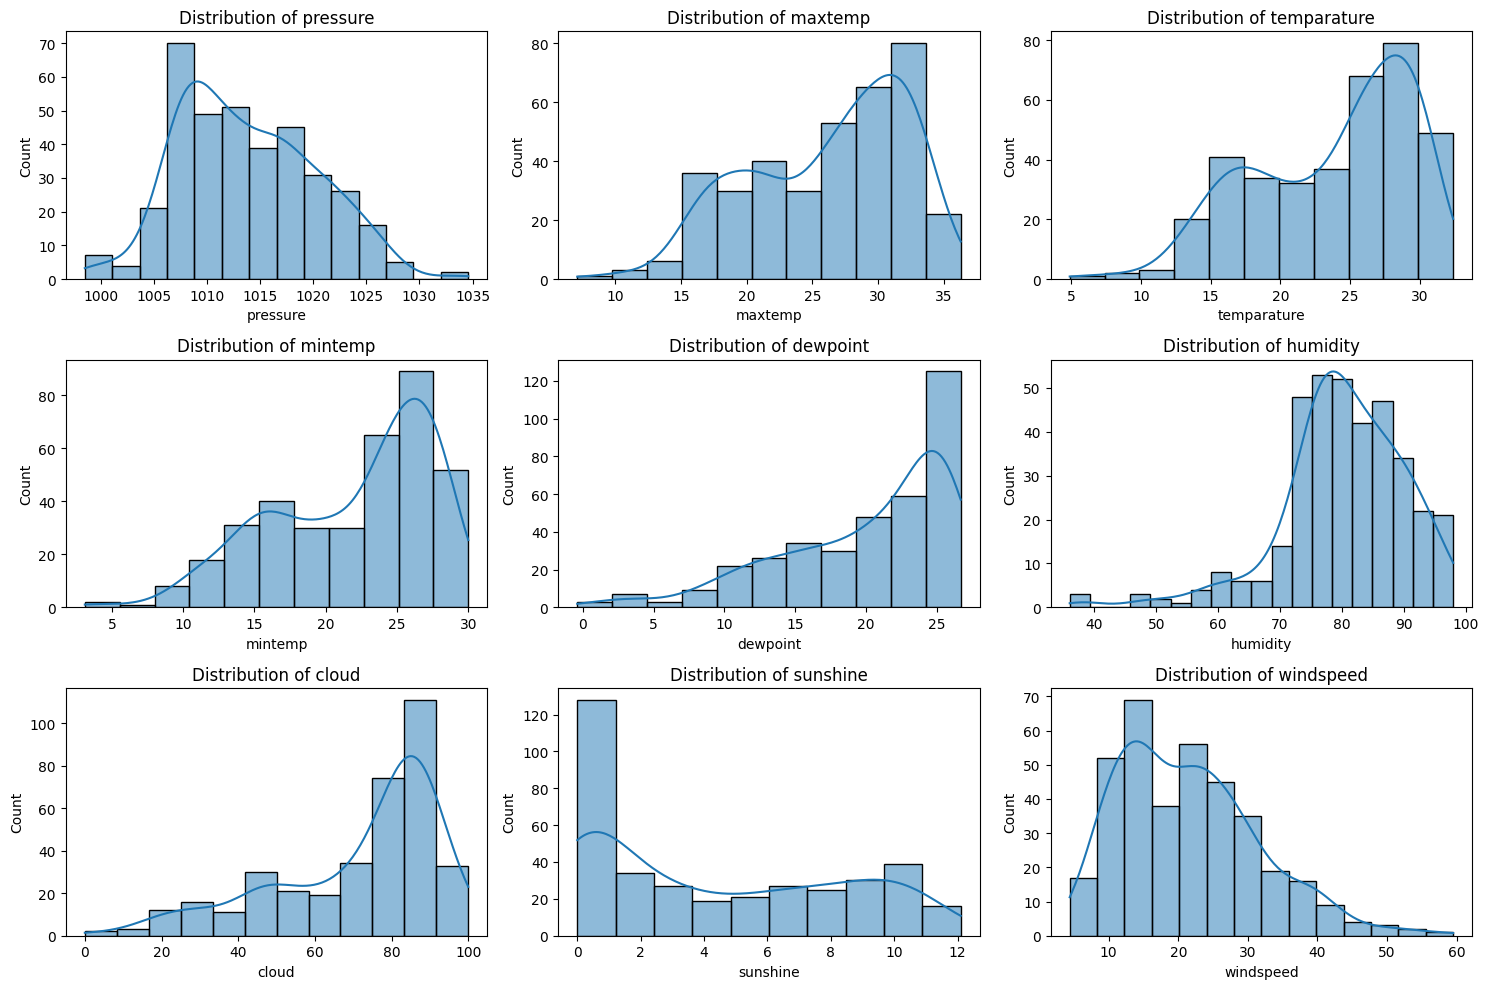

In [17]:
plt.figure(figsize=(15,10))

for i , col in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine', 'windspeed'],1):
    plt.subplot(3,3,i)
    sns.histplot(data[col],kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

##### **Observation:** maxtemp , temperature, mintemp , dewpoint are highly correlated so instead only a single columns will be useful

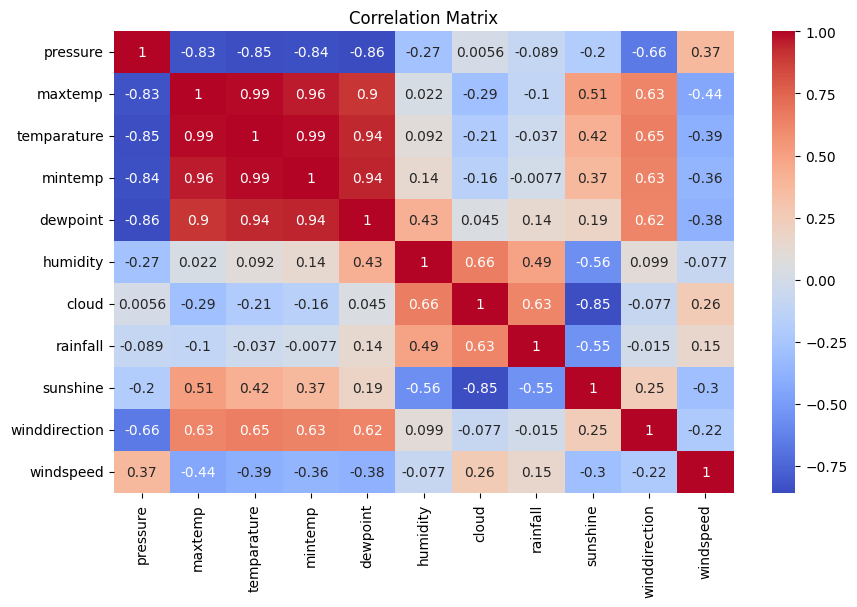

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
# Droped highly correlated columns
df = data.drop(columns=['maxtemp', 'temparature', 'mintemp'])

In [20]:
df.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [21]:
df.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [22]:
# Randomizing the dataset and drop the index col
df = df.sample(frac=1,random_state=42).reset_index(drop=True)

In [23]:
df.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1003.8,25.1,84,88,1,0.0,230.0,16.3
1,1023.6,8.6,77,88,1,0.3,40.0,21.3
2,1013.5,15.6,95,93,1,0.0,60.0,40.0
3,1015.6,22.4,83,81,1,0.5,80.0,30.2
4,1024.7,11.7,79,79,1,5.0,20.0,9.1


##### **Observation:**

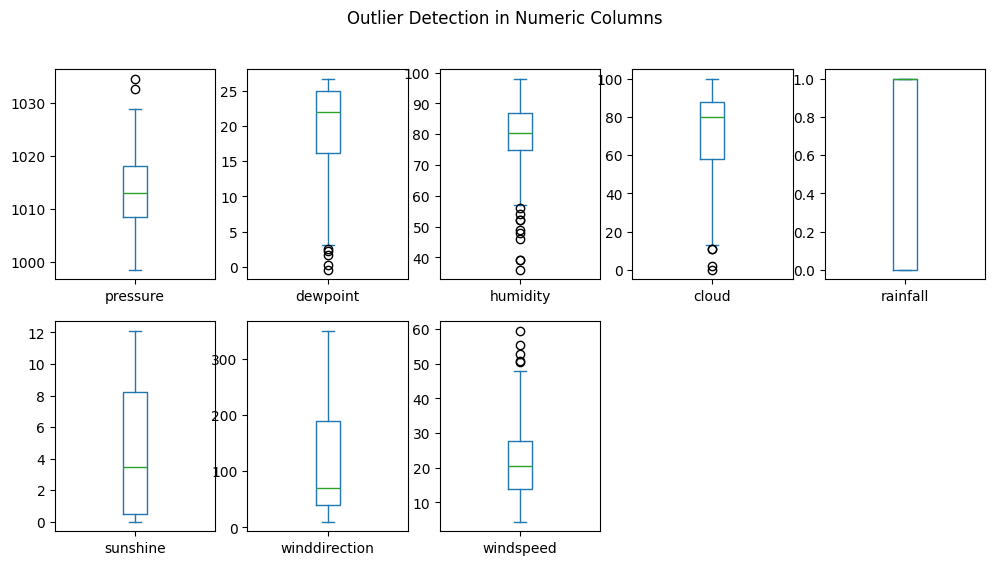

In [24]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols].plot(kind='box', figsize=(12,6), subplots=True, layout=(2,(len(num_cols)//2)+1))
plt.suptitle("Outlier Detection in Numeric Columns")
plt.show()

###### Outlier Removal using IQR

In [25]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_cleaned = df[~((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).any(axis=1)]

print(f"Original shape: {df.shape}")
print(f"Shape after outlier removal: {df_cleaned.shape}")

Original shape: (366, 8)
Shape after outlier removal: (350, 8)


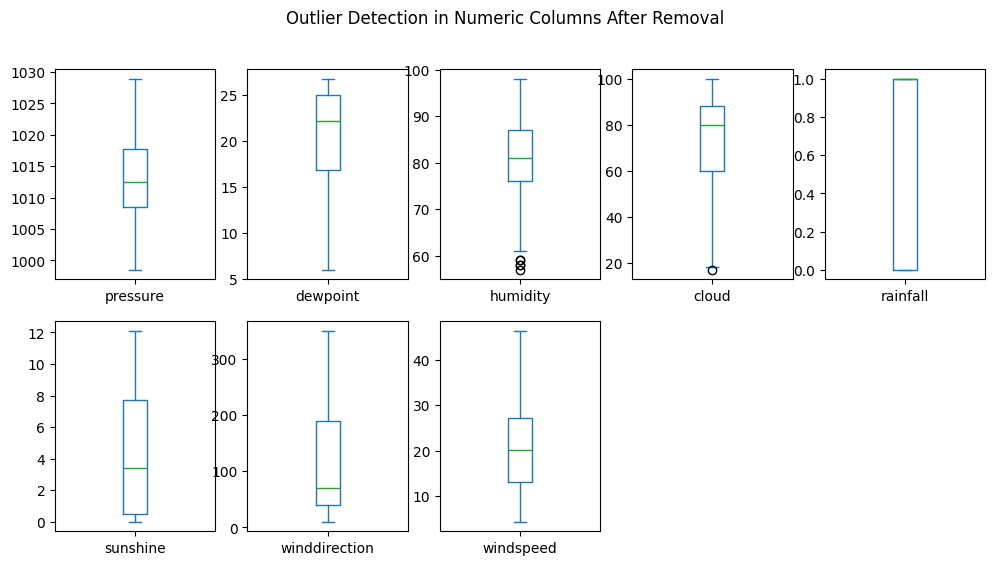

In [26]:
df_cleaned[num_cols].plot(kind='box', figsize=(12,6), subplots=True, layout=(2,(len(num_cols)//2)+1))
plt.suptitle("Outlier Detection in Numeric Columns After Removal")
plt.show()

##### **Observation:** Cloud , sunshine and humidity are most important feature for Rainfall prediction

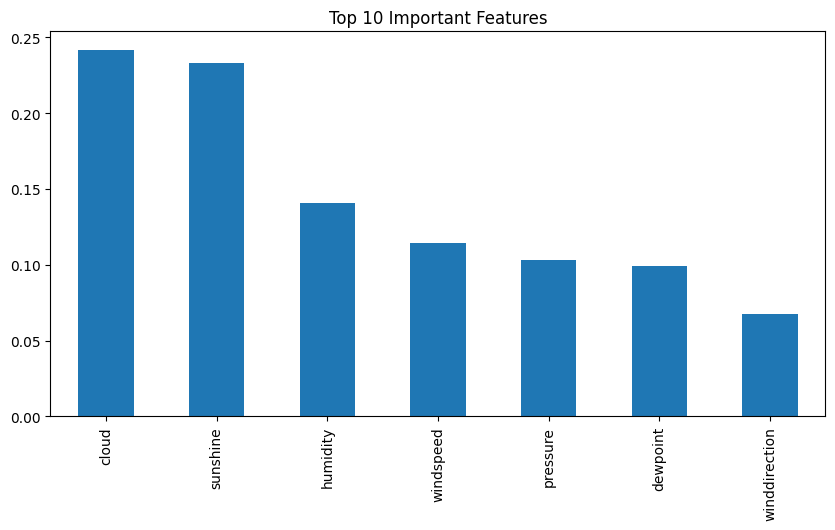

In [27]:
X = df.drop(columns=['rainfall'])
y = df['rainfall']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

#### **Train Test Split**

In [28]:
df_cleaned.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1003.8,25.1,84,88,1,0.0,230.0,16.3
1,1023.6,8.6,77,88,1,0.3,40.0,21.3
2,1013.5,15.6,95,93,1,0.0,60.0,40.0
3,1015.6,22.4,83,81,1,0.5,80.0,30.2
4,1024.7,11.7,79,79,1,5.0,20.0,9.1


In [29]:
X1 = df_cleaned.drop(columns=['rainfall'])
y1 = df_cleaned['rainfall']

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X1,y1,test_size=0.2,random_state=42)

In [31]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
X_train

array([[-0.00946049,  0.04038976,  1.20142688, ..., -0.87562525,
        -0.81021848, -0.66466215],
       [ 1.21689941, -1.17605467, -0.40165004, ...,  0.83549243,
        -0.56228277, -0.71835363],
       [-0.58176178,  0.15443142, -0.15502282, ...,  0.14593754,
        -0.43831492,  0.81722265],
       ...,
       [ 0.54648933, -0.70088107, -0.27833643, ..., -1.0033206 ,
        -0.93418633, -0.82573659],
       [ 0.53013787, -0.62485329,  0.0916044 , ..., -1.02885967,
        -0.68625062, -0.07405589],
       [ 1.52757725, -1.06201301,  0.33823162, ..., -1.13101595,
        -0.93418633, -0.27808351]])

#### Models Training

##### 1. Logistic Regression

In [33]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8
Precision: 0.7962962962962963
Recall: 0.9347826086956522
F1 Score: 0.86

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.54      0.65        24
           1       0.80      0.93      0.86        46

    accuracy                           0.80        70
   macro avg       0.80      0.74      0.76        70
weighted avg       0.80      0.80      0.79        70



##### 2 . Decision Tree

In [35]:
dt = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [36]:
y_pred_dt = dt.predict(X_test)

In [37]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.6714285714285714
Precision: 0.7346938775510204
Recall: 0.782608695652174
F1 Score: 0.7578947368421053

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.46      0.49        24
           1       0.73      0.78      0.76        46

    accuracy                           0.67        70
   macro avg       0.63      0.62      0.62        70
weighted avg       0.66      0.67      0.67        70



##### 3. Random Forest

In [38]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8142857142857143
Precision: 0.8113207547169812
Recall: 0.9347826086956522
F1 Score: 0.8686868686868687

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.58      0.68        24
           1       0.81      0.93      0.87        46

    accuracy                           0.81        70
   macro avg       0.82      0.76      0.78        70
weighted avg       0.82      0.81      0.80        70



##### 4. KNN

In [40]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [41]:
y_pred_knn = knn.predict(X_test)

print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Results
Accuracy: 0.7571428571428571
Precision: 0.8372093023255814
Recall: 0.782608695652174
F1 Score: 0.8089887640449438

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.71      0.67        24
           1       0.84      0.78      0.81        46

    accuracy                           0.76        70
   macro avg       0.73      0.75      0.74        70
weighted avg       0.77      0.76      0.76        70



##### 5. SVM

In [42]:
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [43]:
y_pred_svm = svm.predict(X_test)

print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Results
Accuracy: 0.7714285714285715
Precision: 0.7678571428571429
Recall: 0.9347826086956522
F1 Score: 0.8431372549019608

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.46      0.58        24
           1       0.77      0.93      0.84        46

    accuracy                           0.77        70
   macro avg       0.78      0.70      0.71        70
weighted avg       0.77      0.77      0.75        70



##### 6. Xgboost

In [44]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:21:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [45]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.7285714285714285
Precision: 0.7547169811320755
Recall: 0.8695652173913043
F1 Score: 0.8080808080808081

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.46      0.54        24
           1       0.75      0.87      0.81        46

    accuracy                           0.73        70
   macro avg       0.70      0.66      0.67        70
weighted avg       0.72      0.73      0.71        70



####**Model comparision**

##### Observation : Random Forest gives the highest Accuracy and F1_score

In [46]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_xgb)
    ]
}).sort_values(by='F1 Score', ascending=True)

print("Final Model Comparison:")
display(comparison)

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.671429,0.734694,0.782609,0.757895
5,XGBoost,0.728571,0.754717,0.869565,0.808081
3,KNN,0.757143,0.837209,0.782609,0.808989
4,SVM,0.771429,0.767857,0.934783,0.843137
0,Logistic Regression,0.800000,0.796296,0.934783,0.860000
2,Random Forest,0.814286,0.811321,0.934783,0.868687


/tmp/ipykernel_574/1994563021.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 Score', data=comparison, palette='coolwarm')


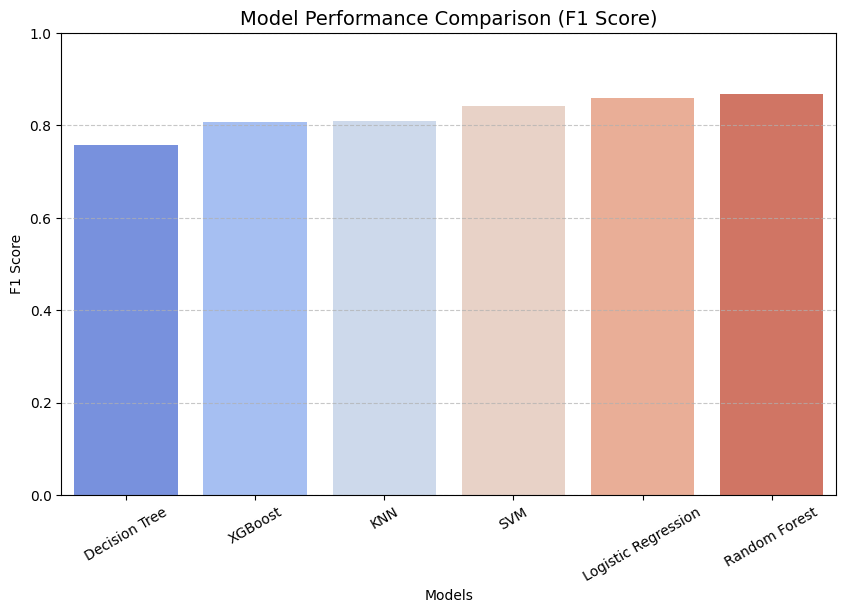

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='F1 Score', data=comparison, palette='coolwarm')
plt.title('Model Performance Comparison (F1 Score)', fontsize=14)
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **Hyperparameter Tuning**

In [48]:
X2 = df_cleaned.drop(columns=['rainfall'])
y2 = df_cleaned['rainfall']

In [49]:
X_train2,X_test2,y_train2,y_test2 = train_test_split(X2,y2,test_size=0.2,random_state=42)

In [50]:
from scipy.stats import randint

In [51]:
param_dist = {
    'n_estimators': np.arange(0, 400, 50),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4],
    'bootstrap': [True, False],
    'max_features': ['sqrt', 'log2']
}

In [52]:
rf = RandomForestClassifier(random_state=42)

In [53]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                # number of random combinations to try
    cv=5,                     # 5-fold cross-validation
    scoring='f1',             # focus on improving F1 score
    verbose=2,
    random_state=42,
    n_jobs=-1                 # use all cores for faster training
)


In [54]:
random_search.fit(X_train2, y_train2)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 3, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': array([  0,  50, 100, 150, 200, 250, 300, 350])},
                   random_state=42, scoring='f1', verbose=2)

In [55]:
print("Best Parameters from RandomizedSearchCV:")
print(random_search.best_params_)

Best Parameters from RandomizedSearchCV:
{'n_estimators': np.int64(300), 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}


#### Final Model

In [56]:
rf_tuned = RandomForestClassifier(n_estimators=300,max_depth=5,min_samples_split=5,min_samples_leaf=4,max_features='log2',random_state=42)
rf_tuned.fit(X_train2, y_train2)
y_pred2 = rf_tuned.predict(X_test2)

In [57]:
print("\nTuned Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test2, y_pred2):.4f}")
print(f"Precision: {precision_score(y_test2, y_pred2):.4f}")
print(f"Recall: {recall_score(y_test2, y_pred2):.4f}")
print(f"F1 Score: {f1_score(y_test2, y_pred2):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))


Tuned Random Forest Results:
Accuracy: 0.8000
Precision: 0.7963
Recall: 0.9348
F1 Score: 0.8600

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.54      0.65        24
           1       0.80      0.93      0.86        46

    accuracy                           0.80        70
   macro avg       0.80      0.74      0.76        70
weighted avg       0.80      0.80      0.79        70



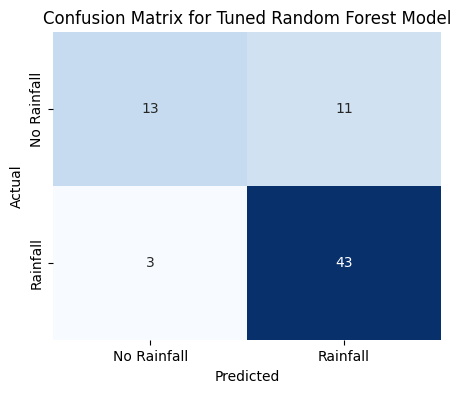

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Rainfall', 'Rainfall'],
            yticklabels=['No Rainfall', 'Rainfall'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Tuned Random Forest Model')
plt.show()

#### Model Saved

In [59]:
X_test2.head()

,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
166,1010.5,25.1,84,85,2.0,180.0,15.4
357,1011.5,20.9,92,90,0.5,50.0,23.7
329,1007.4,25.0,87,88,0.9,40.0,5.7
247,1018.3,16.3,79,89,2.4,40.0,14.8
164,1012.5,19.3,70,43,9.7,60.0,8.9


In [60]:
y_test2.head()

,rainfall
166,0
357,1
329,1
247,1
164,0


In [61]:
import joblib

# Save the model
joblib.dump(rf_tuned, 'rainfall_prediction_model.pkl')

print("Model saved successfully as rainfall_prediction_model.pkl")

Model saved successfully as rainfall_prediction_model.pkl
